# Kaggle submission

Fits the winning model from `2_regularized_regression.ipynb` (sklearn `Lasso`, alpha=0.003162) on the *full* training data and produces `data/submission.csv` for the Kaggle leaderboard.

**Kaggle mechanics** (researched before writing this notebook):
- The competition's evaluation metric is RMSLE (root mean squared log error) between predicted and actual `SalePrice`. Training against `np.log1p(SalePrice)` with plain RMSE -- as every model notebook here already does -- directly optimizes this, so no change to the modeling approach is needed for the metric itself.
- The submission file must have exactly two columns, `Id` and `SalePrice`, matching `data/sample_submission.csv`.
- Actually appearing on the leaderboard requires a Kaggle account that has joined the competition, then uploading the CSV -- either through the competition's *Submit Predictions* page, or via the Kaggle CLI (`kaggle competitions submit`). That step needs the user's own Kaggle credentials, so it's documented at the bottom of this notebook rather than run here.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDINAL_COLS
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
BEST_LASSO_ALPHA = 0.003162  # picked in 2_regularized_regression.ipynb


## Load data, drop outliers, build the target

`Id` 524/1299 are the two outliers flagged in `6_outliers.ipynb`. Unlike `2_regularized_regression.ipynb`, there's no train/val split here -- this is the final fit, so every remaining labeled row is used for training. The pipeline is fit on train and applied to test with `transform` only, to avoid leaking test statistics into `StandardScaler`.

In [2]:
df_train = pd.read_csv("../../data/train.csv")
df_train = df_train[~df_train["Id"].isin([524, 1299])]
df_test = pd.read_csv("../../data/test.csv")

X_train_raw = df_train[FEATURE_COLS]
X_test_raw = df_test[FEATURE_COLS]
y_train = np.log1p(df_train["SalePrice"]).to_numpy()

pipeline = build_pipeline()
X_train = pipeline.fit_transform(X_train_raw).to_numpy()
X_test = pipeline.transform(X_test_raw).to_numpy()
X_train.shape, X_test.shape


((1458, 237), (1459, 237))

## Fit the best model on the full training data

sklearn `Lasso(alpha=0.003162)` was the best single model across notebooks 2-4 (lowest validation RMSE in log space, confirmed by 5-fold CV).

In [3]:
model = Lasso(alpha=BEST_LASSO_ALPHA)
model.fit(X_train, y_train)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.003162
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


## Predict on the test set and invert the log transform

The model predicts `log1p(SalePrice)`; `np.expm1` inverts it back to dollars for submission.

In [4]:
log_pred = model.predict(X_test)
sale_price_pred = np.expm1(log_pred)
pd.Series(sale_price_pred).describe()


count      1459.000000
mean     178061.663471
std       74591.044054
min       40153.222430
25%      127084.344524
50%      157463.178601
75%      212319.066772
max      672436.559679
dtype: float64

## Sanity check: predicted vs. training price distribution

A quick shape comparison to catch anything obviously broken (e.g. negative prices, a wildly different scale) before writing the submission file.

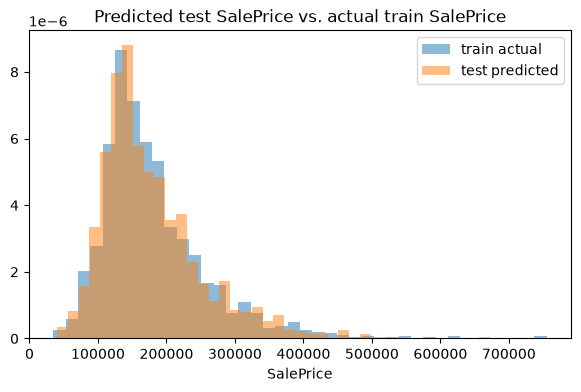

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_train["SalePrice"], bins=40, alpha=0.5, density=True, label="train actual")
ax.hist(sale_price_pred, bins=40, alpha=0.5, density=True, label="test predicted")
ax.set_xlabel("SalePrice")
ax.legend()
ax.set_title("Predicted test SalePrice vs. actual train SalePrice")
plt.show()

assert (sale_price_pred > 0).all(), "negative predicted prices"


## Write the submission file

Matches `data/sample_submission.csv`'s two-column format exactly.

In [6]:
submission = pd.DataFrame({"Id": df_test["Id"], "SalePrice": sale_price_pred})
submission.to_csv("../../data/submission.csv", index=False)
submission.head()


,Id,SalePrice
0,1461,116510.507859
1,1462,156747.282580
2,1463,177329.641463
3,1464,191591.541978
4,1465,203654.113376


## Submitting to Kaggle

`data/submission.csv` is ready. `data/` isn't versioned in this repo, so uploading it is a manual, one-time action tied to your own Kaggle account -- not something to script here. Either:

1. **Web UI**: join the competition [here](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) if you haven't, open its *Submit Predictions* tab, upload `data/submission.csv`, add a short description, and click *Make Submission*.
2. **Kaggle CLI** (if `~/.kaggle/kaggle.json` API credentials are already set up):
   ```shell
   kaggle competitions submit \
     -c house-prices-advanced-regression-techniques \
     -f data/submission.csv \
     -m "Lasso alpha=0.003162, full-pipeline features"
   ```

This is a perpetual "Getting Started" competition with a rolling leaderboard, but per-day submission caps still apply and vary -- check the competition's rules page if a submission is rejected for hitting the limit.